In [74]:
# Imports
import matplotlib.pyplot as plt
import pandas as pd

In [75]:
co2_df = pd.read_csv("UK/co2.csv", names=["CO2/Kwh"])
demand_df = pd.read_csv("UK/demand.csv", names=["demand"])
pv_df = pd.read_csv("UK/pv.csv", names=["pv_kw"])

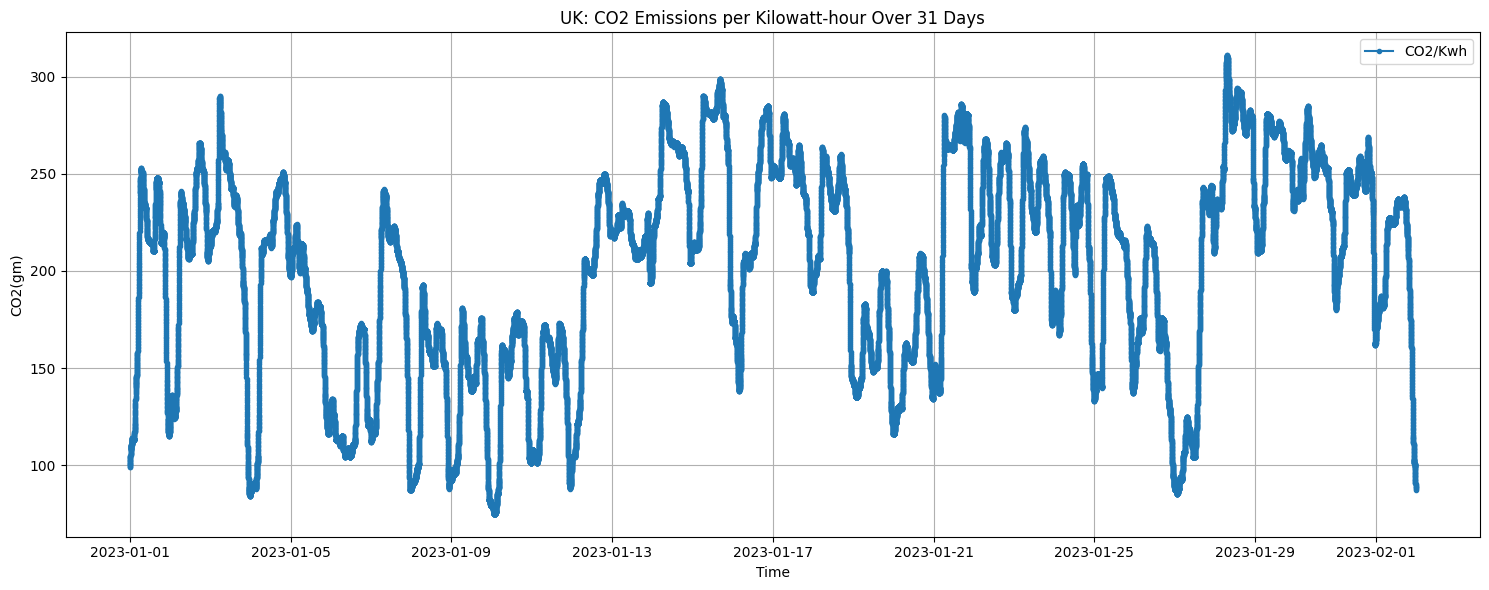

In [76]:
time_index = pd.date_range(start='2023-01-01', periods=len(co2_df['CO2/Kwh']), freq='1T')
# Plot the data
plt.figure(figsize=(15, 6))
plt.plot(time_index, co2_df['CO2/Kwh'], linestyle='-', marker='o', markersize=3, label='CO2/Kwh')
plt.xlabel('Time')
plt.ylabel('CO2(gm)')
plt.title('UK: CO2 Emissions per Kilowatt-hour Over 31 Days')
plt.grid(True)
plt.legend()
plt.tight_layout()

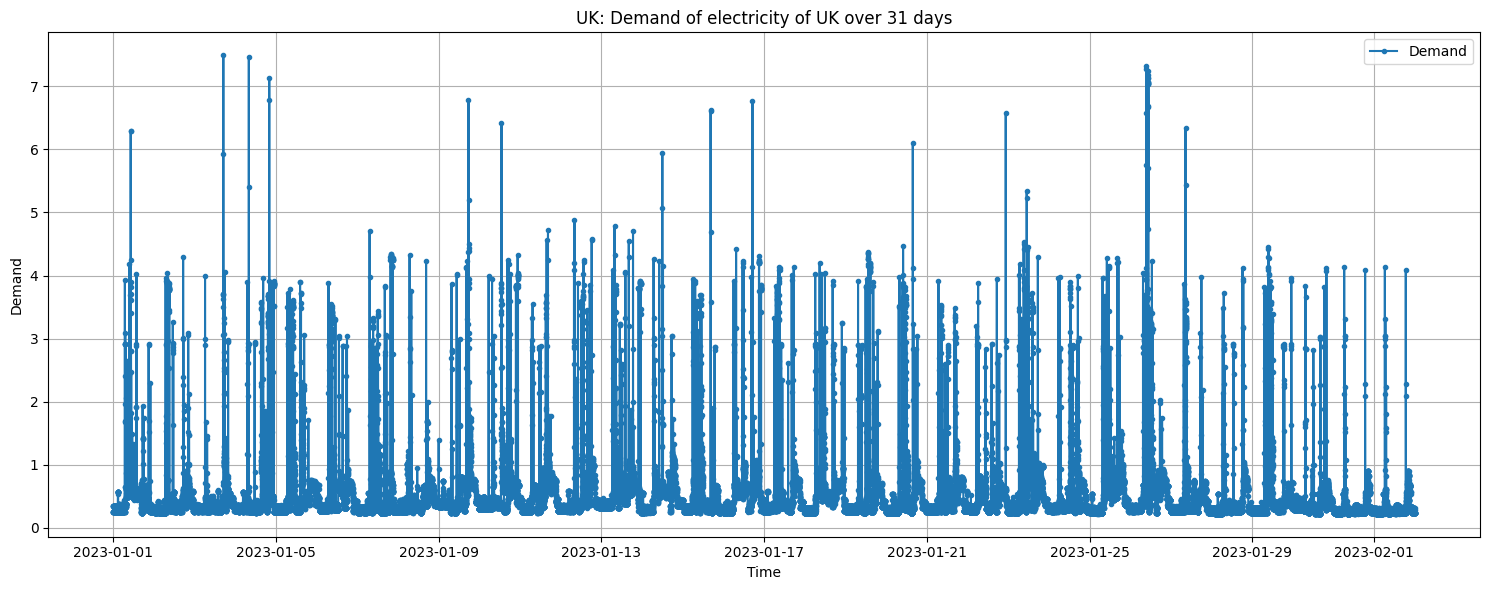

In [77]:
time_index = pd.date_range(start='2023-01-01', periods=len(demand_df['demand']), freq='1T')
# Plot the data
plt.figure(figsize=(15, 6))
plt.plot(time_index, demand_df['demand'], linestyle='-', marker='o', markersize=3, label='Demand')
plt.xlabel('Time')
plt.ylabel('Demand')
plt.title('UK: Demand of electricity of UK over 31 days')
plt.grid(True)
plt.legend()
plt.tight_layout()

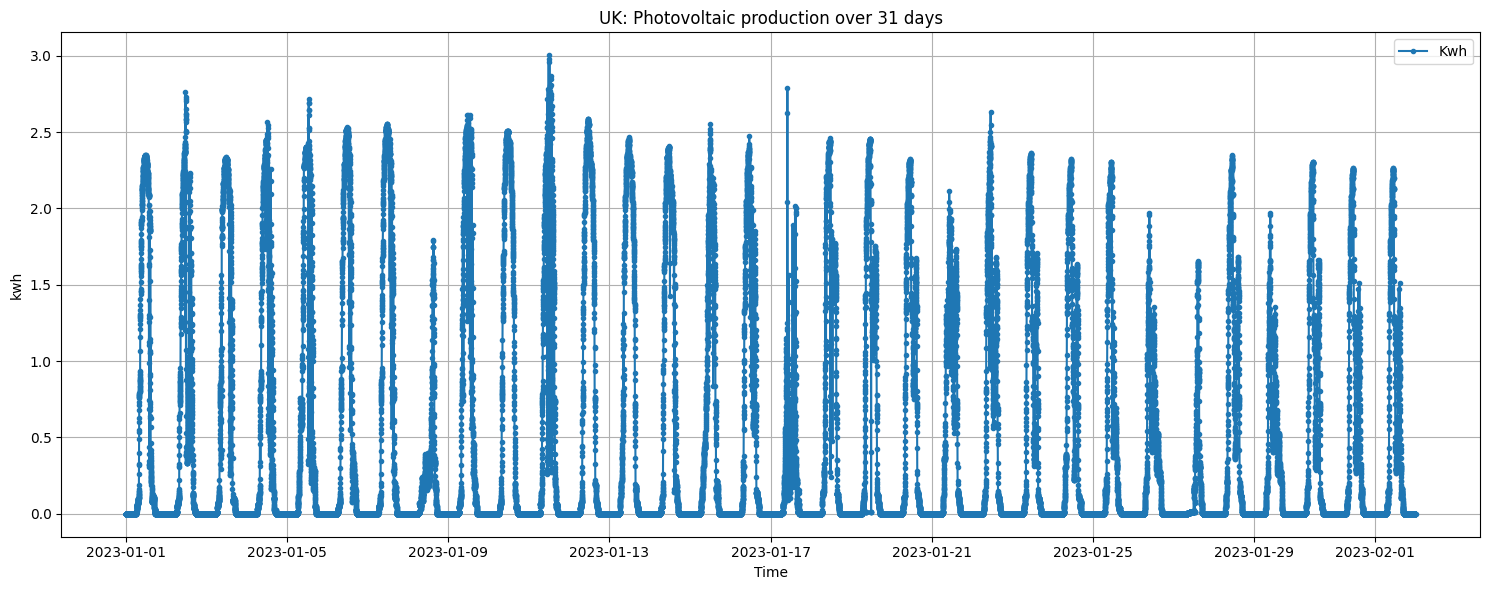

In [78]:
time_index = pd.date_range(start='2023-01-01', periods=len(pv_df["pv_kw"]), freq='1T')
# Plot the data
plt.figure(figsize=(15, 6))
plt.plot(time_index, pv_df["pv_kw"], linestyle='-', marker='o', markersize=3, label='Kwh')
plt.xlabel('Time')
plt.ylabel('kwh')
plt.title('UK: Photovoltaic production over 31 days')
plt.grid(True)
plt.legend()
plt.tight_layout()

# 24 hours

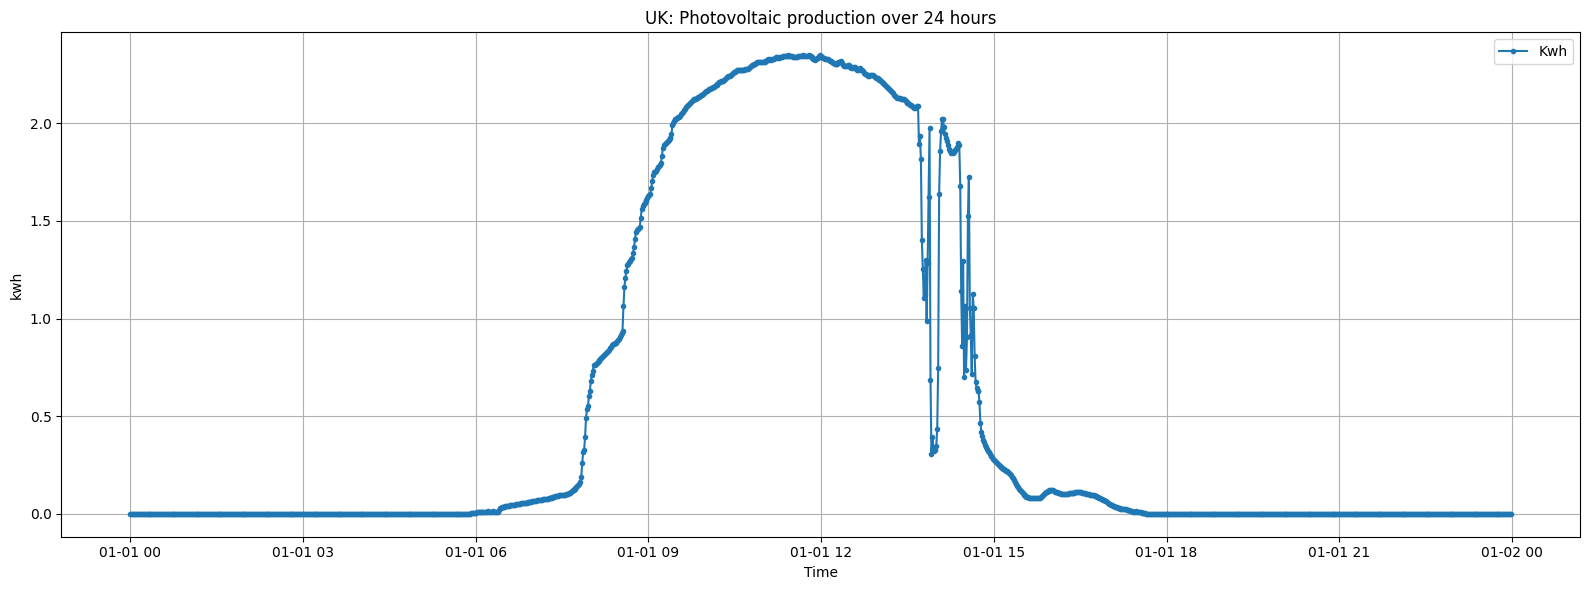

In [79]:
data = pd.read_csv('UK/pv.csv',header=None, names=['pv_kw'])
data_one_day = data.iloc[:24 * 60]

time_index = pd.date_range(start='2023-01-01', periods=len(data_one_day), freq='1T')
# Plot the data
plt.figure(figsize=(16, 6))
plt.plot(time_index, data_one_day, linestyle='-', marker='o', markersize=3, label='Kwh')
plt.xlabel('Time')
plt.ylabel('kwh')
plt.title('UK: Photovoltaic production over 24 hours')
plt.grid(True)
plt.legend()
plt.tight_layout()

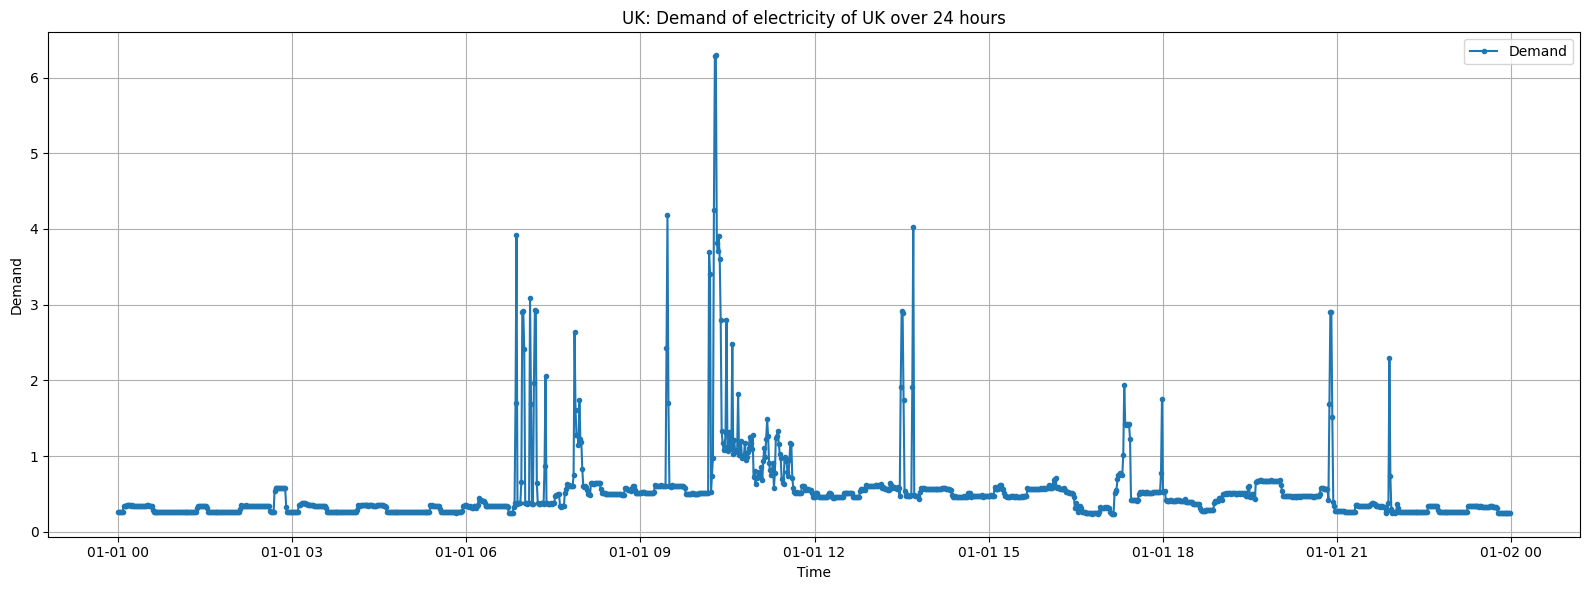

In [80]:
data = pd.read_csv('UK/demand.csv',header=None, names=['demand'])
data_one_day = data.iloc[0:24*60]

time_index = pd.date_range(start='2023-01-01', periods=len(data_one_day), freq='1T')
# Plot the data
plt.figure(figsize=(16, 6))
plt.plot(time_index, data_one_day, linestyle='-', marker='o', markersize=3, label='Demand')
plt.xlabel('Time')
plt.ylabel('Demand')
plt.title('UK: Demand of electricity of UK over 24 hours')
plt.grid(True)
plt.legend()
plt.tight_layout()

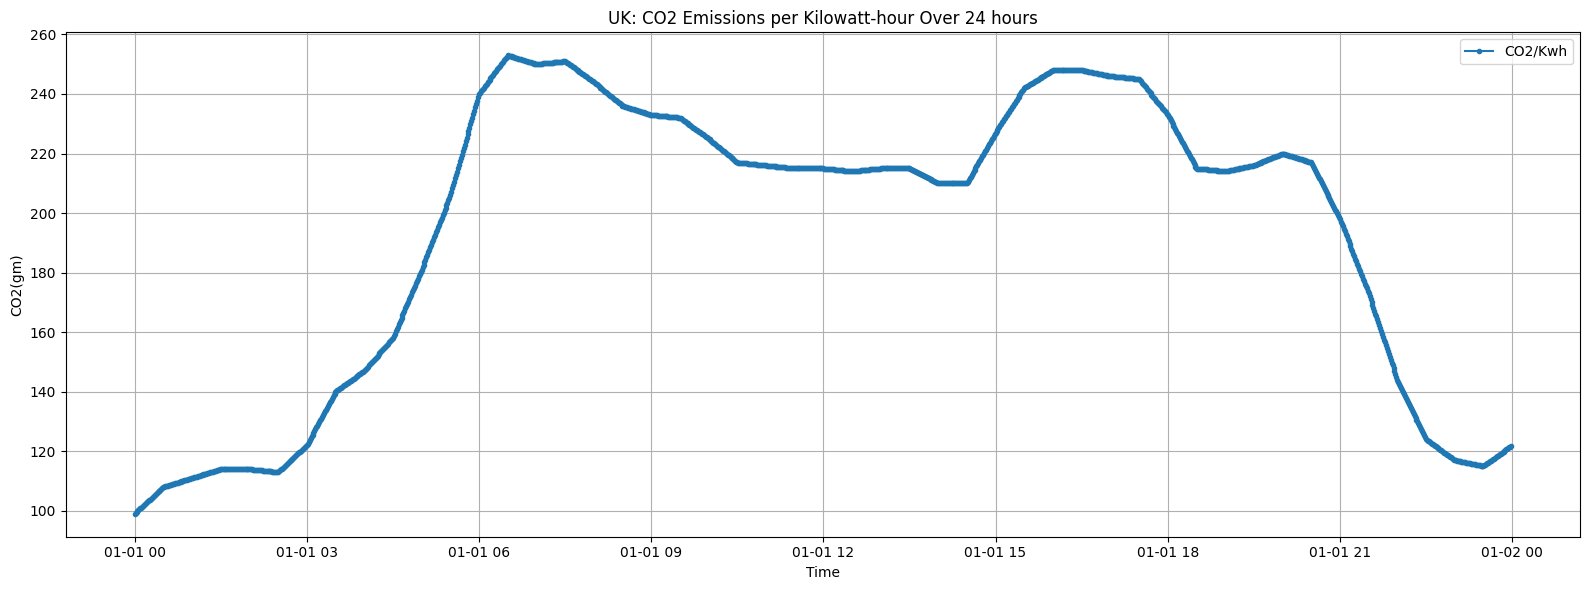

In [81]:
data = pd.read_csv('UK/co2.csv',header=None, names=['CO2/Kwh'])
data_one_day = data.iloc[0:24*60]

time_index = pd.date_range(start='2023-01-01', periods=len(data_one_day), freq='1T')
# Plot the data
plt.figure(figsize=(16, 6))
plt.plot(time_index, data_one_day, linestyle='-', marker='o', markersize=3, label='CO2/Kwh')
plt.xlabel('Time')
plt.ylabel('CO2(gm)')
plt.title('UK: CO2 Emissions per Kilowatt-hour Over 24 hours')
plt.grid(True)
plt.legend()
plt.tight_layout()

# Scenario 1

Co2 Emissions: 5,114,460.325413085
Total electricity usage: 24727.078337560997


/var/folders/nw/y1x5c01x11l4zqclcx59zjpm0000gn/T/ipykernel_49238/2141039894.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f'Total electricity usage: {demand_df.sum()[0]}')


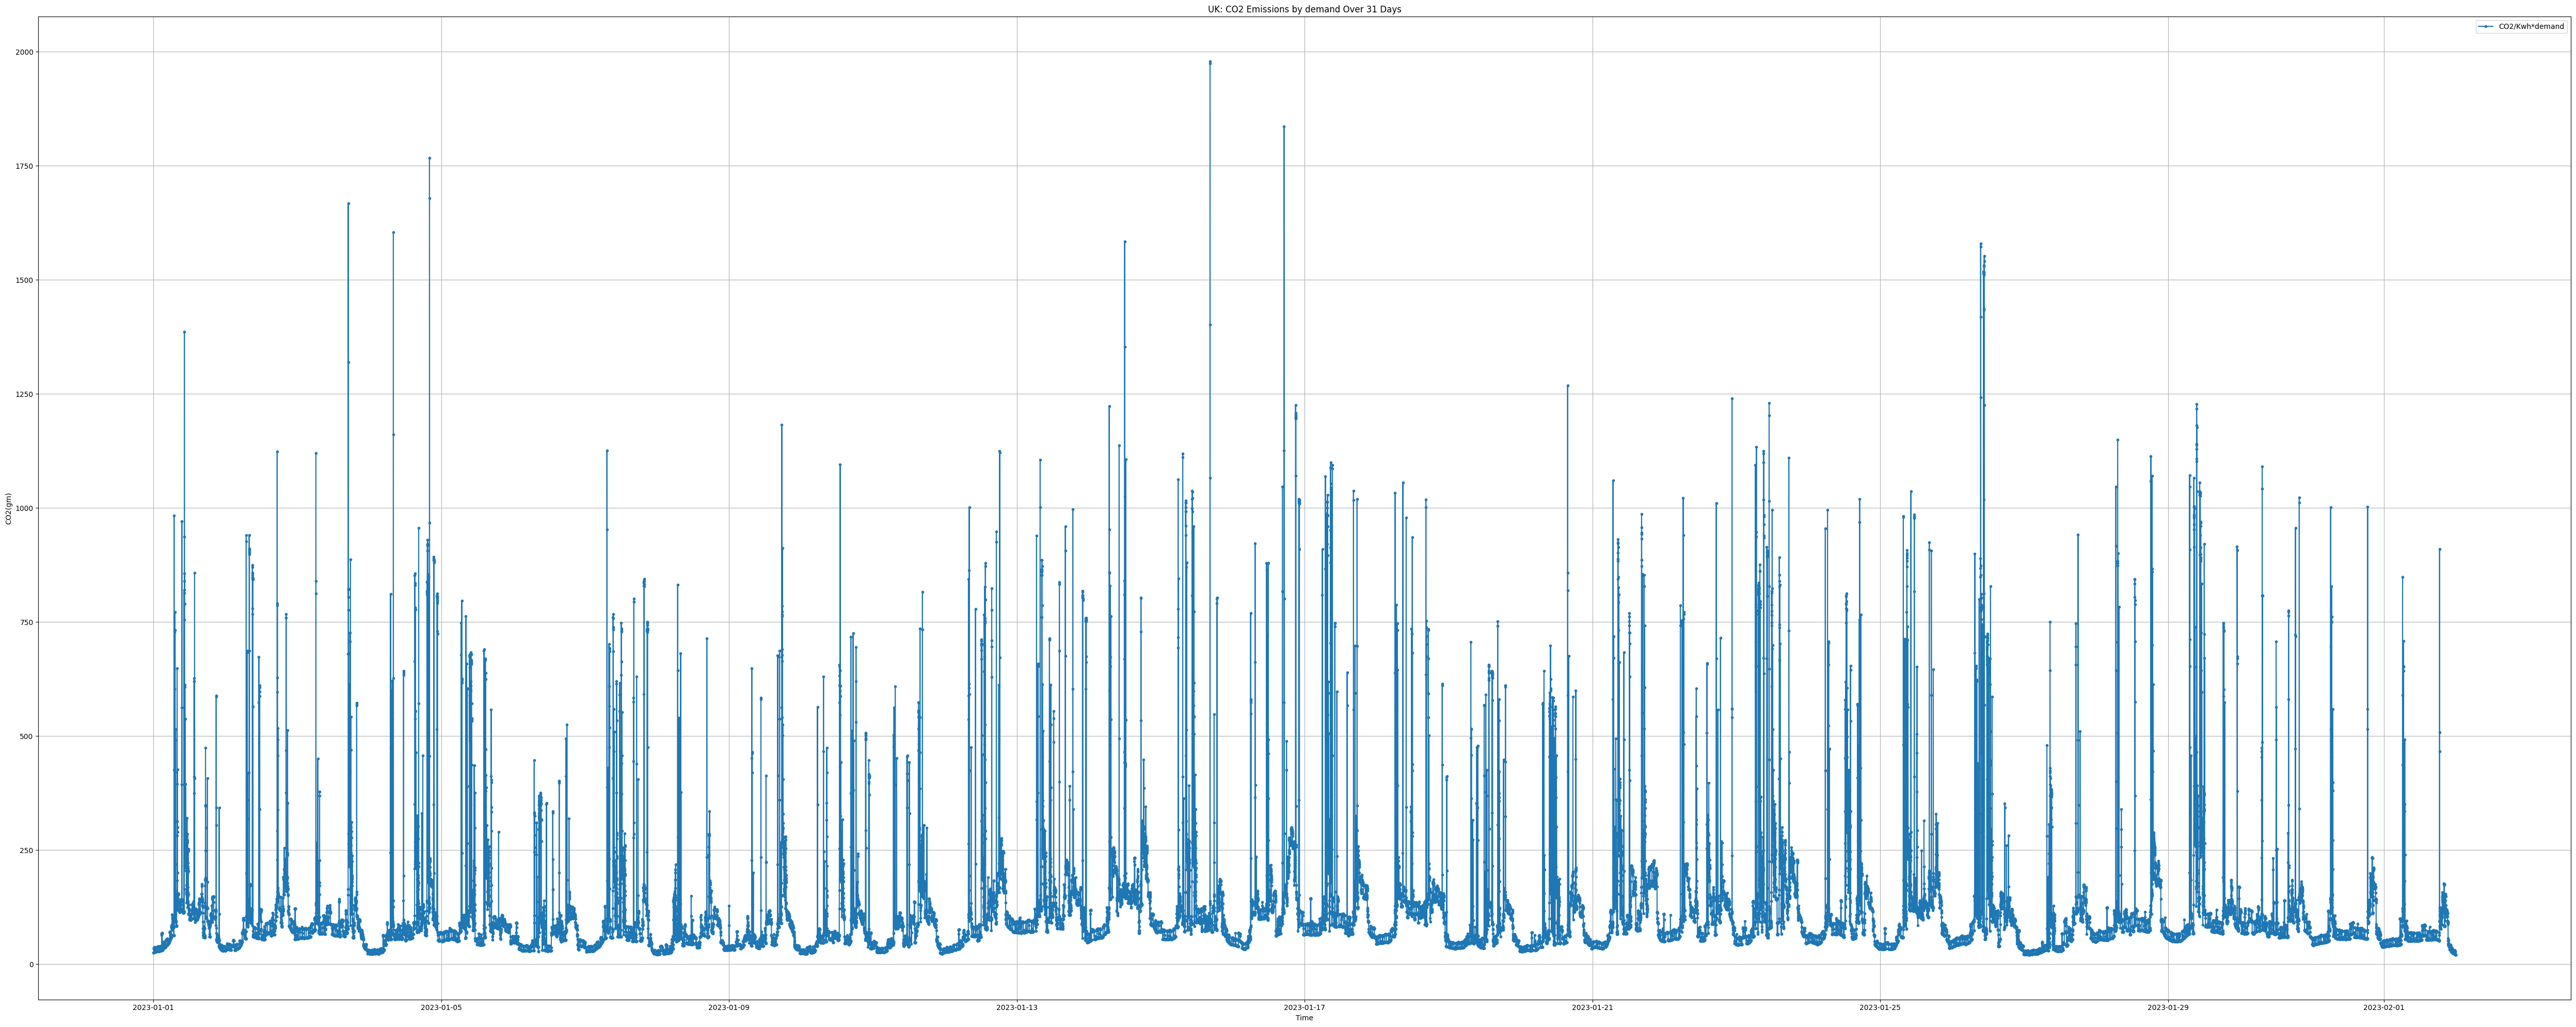

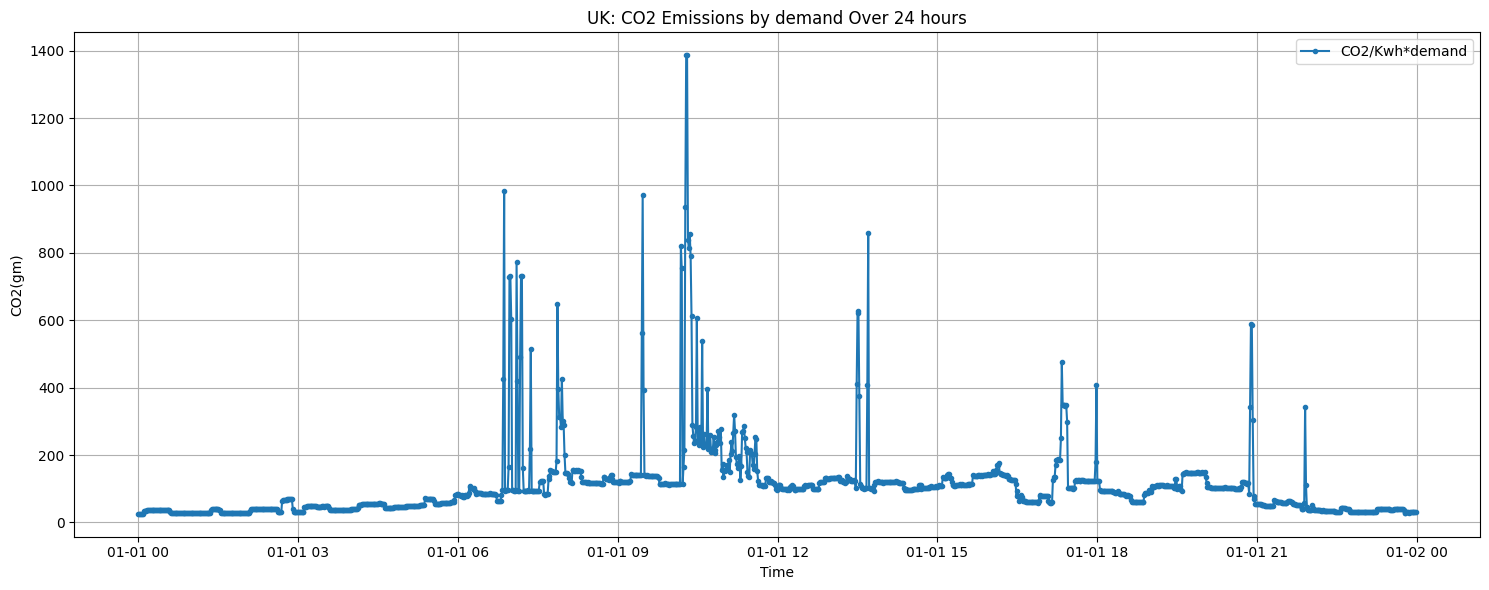

In [82]:
# Multiply the two DataFrames
result_df_grid = pd.DataFrame(co2_df.values*demand_df.values)
time_index = pd.date_range(start='2023-01-01', periods=len(co2_df['CO2/Kwh']), freq='1T')
# Plot the result data

plt.figure(figsize=(50, 20))
plt.plot(time_index, result_df_grid, linestyle='-', marker='o', markersize=3, label='CO2/Kwh*demand')
plt.xlabel('Time')
plt.ylabel('CO2(gm)')
plt.title('UK: CO2 Emissions by demand Over 31 Days')
plt.grid(True)
plt.legend()
plt.tight_layout()

value = result_df_grid.sum()[0]
print(f'Co2 Emissions: {value:,}')
print(f'Total electricity usage: {demand_df.sum()[0]}')

print("="*30)
result_df_grid_24 = result_df_grid.iloc[:24*60]
time_index = pd.date_range(start='2023-01-01', periods=len(result_df_grid_24), freq='1T')
plt.figure(figsize=(15, 6))
plt.plot(time_index, result_df_grid_24, linestyle='-', marker='o', markersize=3, label='CO2/Kwh*demand')
plt.xlabel('Time')
plt.ylabel('CO2(gm)')
plt.title('UK: CO2 Emissions by demand Over 24 hours')
plt.grid(True)
plt.legend()
plt.tight_layout()

# Scenario 2

Co2 Emissions: 3,452,490.902019281
Total electricity usage: 16992.9457278109
Total pv excess: 13140.72606998349


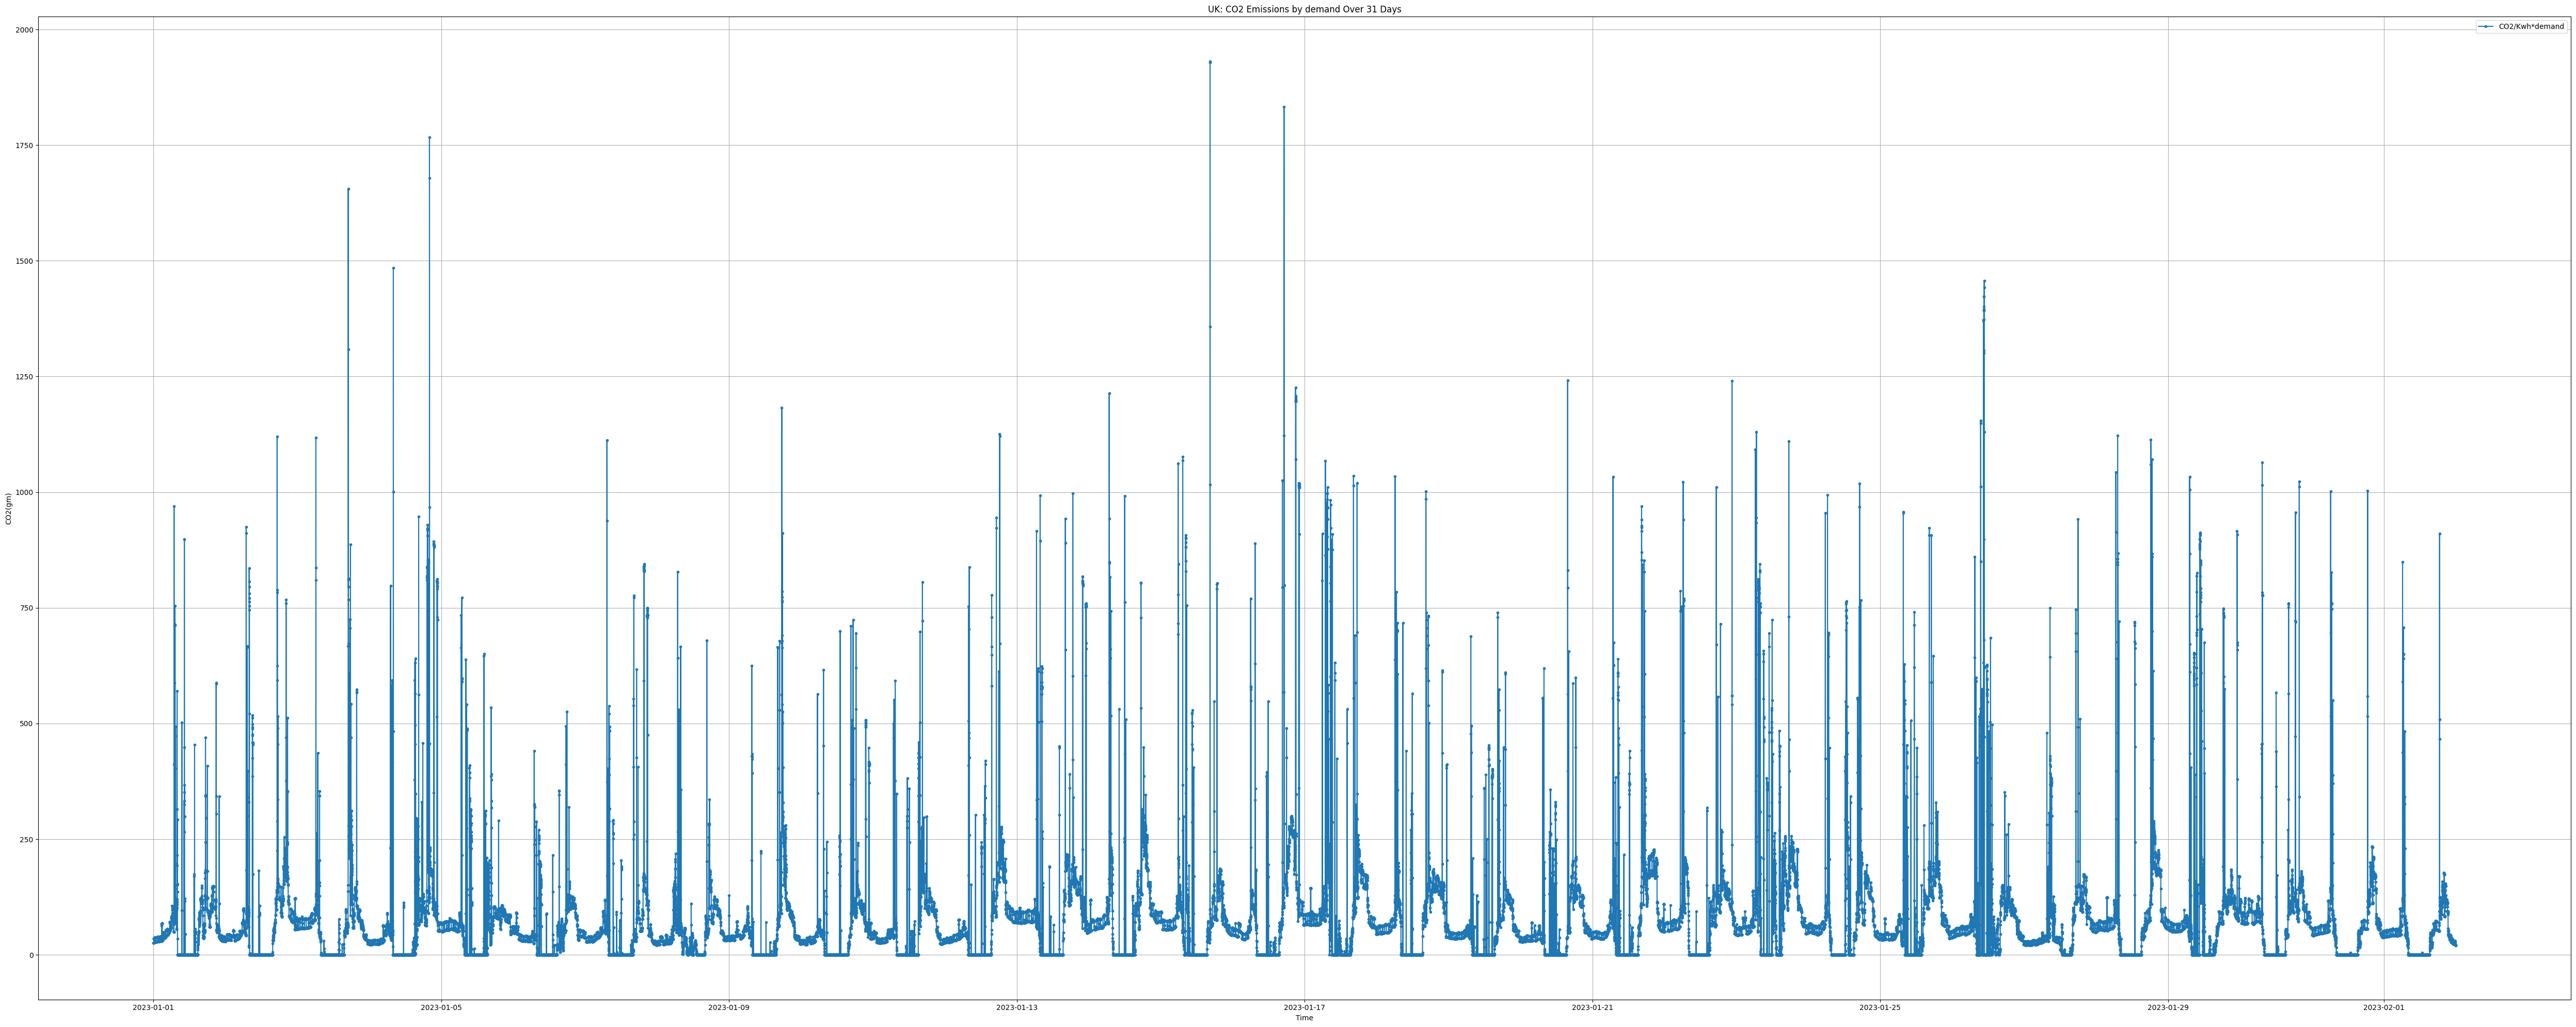

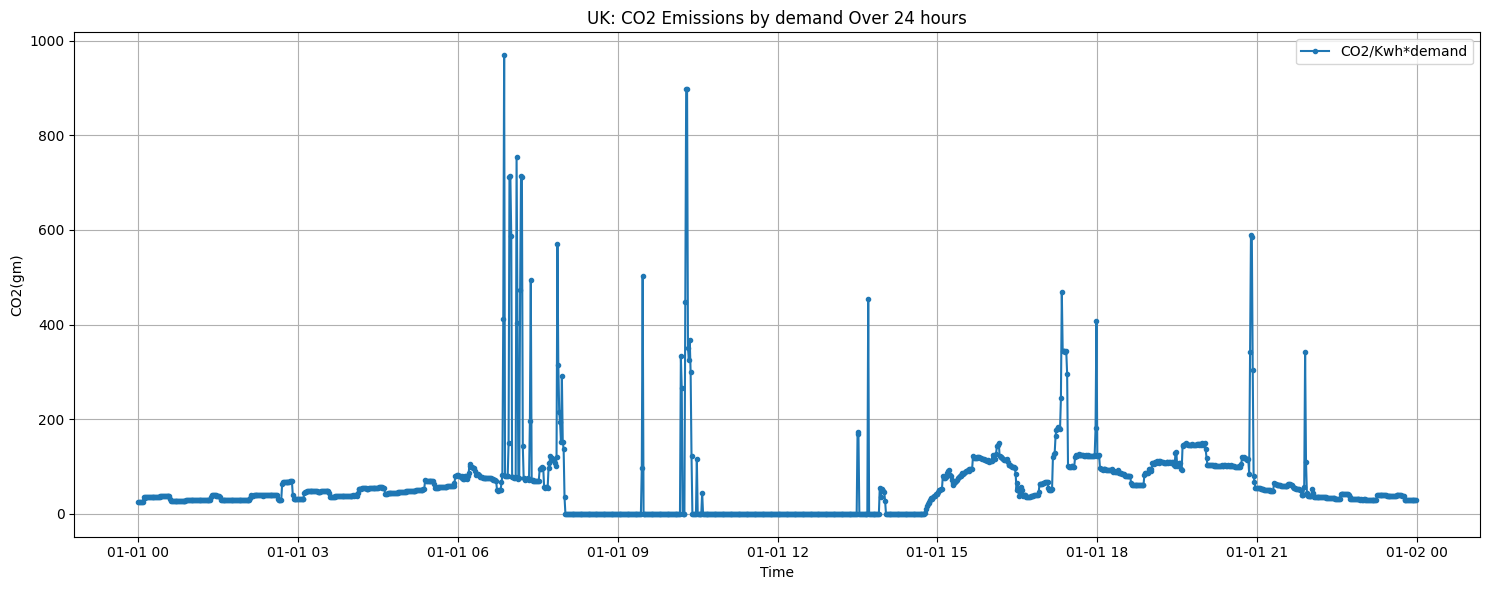

In [83]:
# Multiply the two DataFrames
net_kw_df = demand_df.values - pv_df.values
excess_df = net_kw_df[net_kw_df < 0]
net_kw_df[net_kw_df < 0] = 0
result_df_grid = pd.DataFrame(co2_df.values*net_kw_df)
time_index = pd.date_range(start='2023-01-01', periods=len(co2_df['CO2/Kwh']), freq='1T')
# Plot the result data

plt.figure(figsize=(50, 20))
plt.plot(time_index, result_df_grid, linestyle='-', marker='o', markersize=3, label='CO2/Kwh*demand')
plt.xlabel('Time')
plt.ylabel('CO2(gm)')
plt.title('UK: CO2 Emissions by demand Over 31 Days')
plt.grid(True)
plt.legend()
plt.tight_layout()

value = result_df_grid.sum()[0]
print(f'Co2 Emissions: {value:,}')
print(f'Total electricity usage: {net_kw_df.sum()}')
print(f'Total pv excess: {abs(excess_df.sum())}')

print("="*30)
result_df_grid_24 = result_df_grid.iloc[:24*60]
time_index = pd.date_range(start='2023-01-01', periods=len(result_df_grid_24), freq='1T')
plt.figure(figsize=(15, 6))
plt.plot(time_index, result_df_grid_24, linestyle='-', marker='o', markersize=3, label='CO2/Kwh*demand')
plt.xlabel('Time')
plt.ylabel('CO2(gm)')
plt.title('UK: CO2 Emissions by demand Over 24 hours')
plt.grid(True)
plt.legend()
plt.tight_layout()

# Scenario 3

In [84]:
import pandas as pd

co2_df = pd.read_csv('UK/co2.csv')
demand_df = pd.read_csv('UK/demand.csv')
pv_df = pd.read_csv('UK/pv.csv')

co2_values = co2_df.iloc[:, 0].tolist()
demand_values = demand_df.iloc[:, 0].tolist()
pv_values = pv_df.iloc[:, 0].tolist()

net_kw = []
battery_storage = 0
battery_limit = 13.5
excess = 0

for i in range(len(co2_values)):
    net_value = demand_values[i] - pv_values[i]
    if net_value < 0:
        battery_storage += abs(net_value)
        if battery_storage > 13.5:
            excess += (battery_storage - battery_limit)
            battery_storage = 13.5
    else:
        if battery_storage >= net_value:
            battery_storage -= net_value
            if battery_storage < 0:
                battery_storage = 0
            net_kw.append(0)
        else:
            net_kw.append(net_value - battery_storage)
            battery_storage = 0

total_co2 = sum(co2 * kw for co2, kw in zip(co2_values, net_kw))
print(f'Co2 emissions: {total_co2:,}')
print(f'Total electricity usage: {sum(net_kw):,}')
print(f'Total pv excess: {excess:,}')

Co2 emissions: 3,124,104.4695849614
Total electricity usage: 15,867.119434822918
Total pv excess: 12,015.15792699544


# Optimize

In [85]:
# Constants
BATTERY_LIMIT = 13.5
CO2_THRESHOLD = 200
CHARGING_RATE_MIN = 0.05

co2_df = pd.read_csv('UK/co2.csv')
demand_df = pd.read_csv('UK/demand.csv')
pv_df = pd.read_csv('UK/pv.csv')

co2_values = co2_df.iloc[:, 0].tolist()
demand_values = demand_df.iloc[:, 0].tolist()
pv_values = pv_df.iloc[:, 0].tolist()

net_kw = []
battery_storage = 0
excess = 0
charging_draw_co2 = 0
charging_draw_electricity = 0

for i in range(len(co2_values)):
    net_value = demand_values[i] - pv_values[i]

    if net_value < 0:
        battery_storage += abs(net_value)
        if battery_storage > BATTERY_LIMIT:
            excess += (battery_storage - BATTERY_LIMIT)
            battery_storage = BATTERY_LIMIT
    else:
        if co2_values[i] > CO2_THRESHOLD:
            deficit = min(battery_storage, abs(net_value))
            battery_storage -= deficit
            net_kw.append(net_value - deficit)
        else:
            deficit = min(battery_storage, abs(net_value))
            battery_storage -= deficit
            net_kw.append(net_value - deficit)

            if battery_storage < BATTERY_LIMIT:
                charging_draw = min(BATTERY_LIMIT - battery_storage, CHARGING_RATE_MIN)
                battery_storage += charging_draw
                charging_draw_electricity += charging_draw_electricity
                charging_draw_co2 += charging_draw * co2_values[i]

total_co2 = sum(co2 * kw for co2, kw in zip(co2_values, net_kw)) + charging_draw_co2
total_usage = sum(net_kw) + charging_draw_electricity
total_excess = excess

print(f'Co2 emissions: {total_co2:,}')
print(f'Total electricity usage: {total_usage:,}')
print(f'Total pv excess: {total_excess:,}')


Co2 emissions: 3,089,580.5621982724
Total electricity usage: 15,067.37897589483
Total pv excess: 12,024.143876996435
